In [15]:

import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt
df = pd.read_parquet('../data/processed/model_df.parquet')

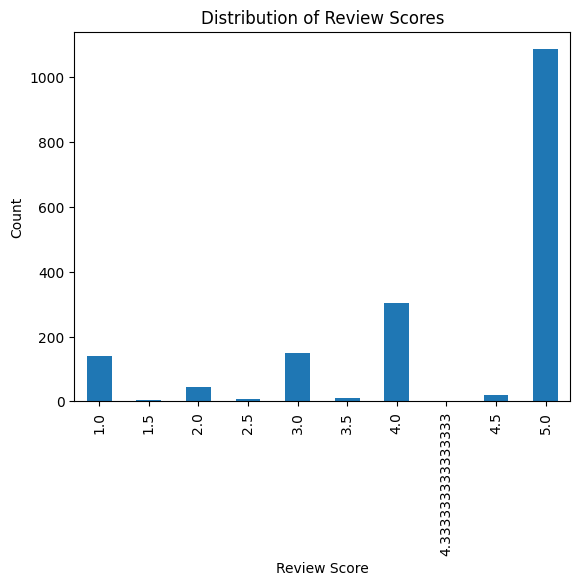

In [16]:
df['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

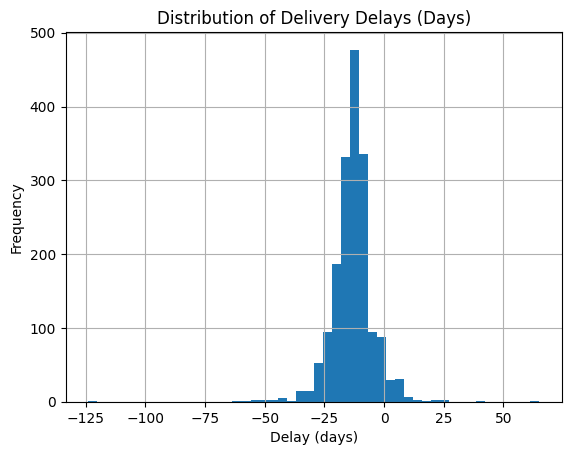

In [17]:
df['delivery_delay_days'].hist(bins=50)
plt.title("Distribution of Delivery Delays (Days)")
plt.xlabel("Delay (days)")
plt.ylabel("Frequency")
plt.show()

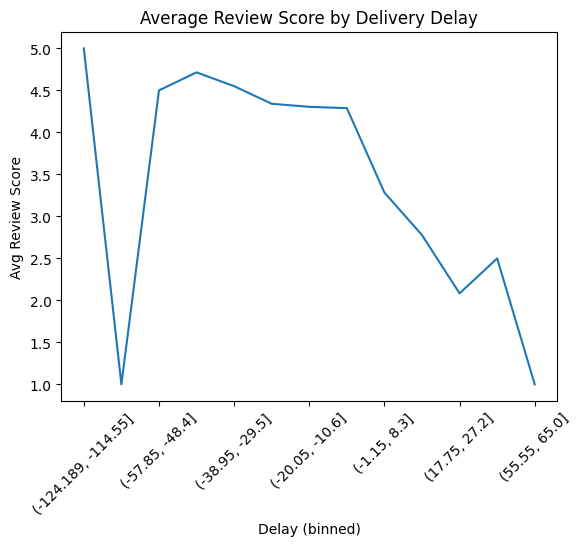

In [18]:


delay_bins = pd.cut(df['delivery_delay_days'], bins=20)

avg_review_by_delay = df.groupby(delay_bins)['review_score'].mean()

avg_review_by_delay.plot()
plt.xticks(rotation=45)
plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delay (binned)")
plt.ylabel("Avg Review Score")
plt.show()

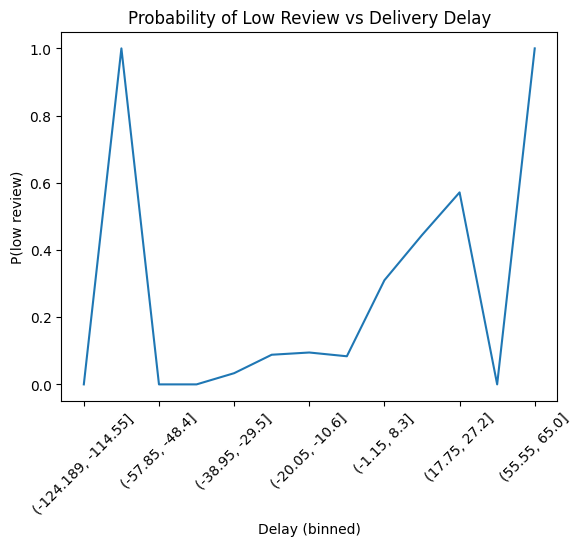

In [19]:
df['low_review'] = (df['review_score'] <= 2).astype(int)

delay_bins = pd.cut(df['delivery_delay_days'], bins=20)

bad_rate = df.groupby(delay_bins)['low_review'].mean()

bad_rate.plot()
plt.xticks(rotation=45)
plt.title("Probability of Low Review vs Delivery Delay")
plt.xlabel("Delay (binned)")
plt.ylabel("P(low review)")
plt.show()

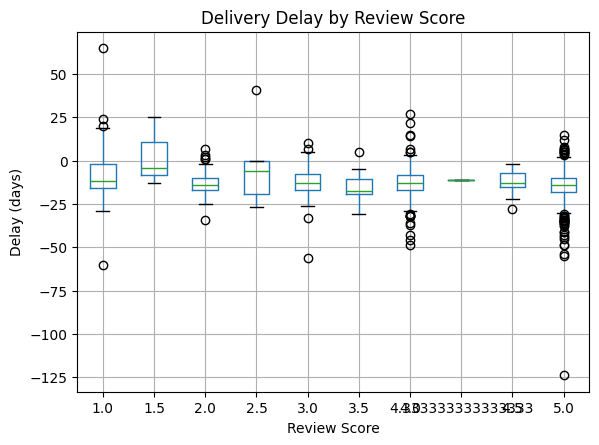

In [20]:
df.boxplot(column='delivery_delay_days', by='review_score')
plt.title("Delivery Delay by Review Score")
plt.suptitle("")
plt.xlabel("Review Score")
plt.ylabel("Delay (days)")
plt.show()

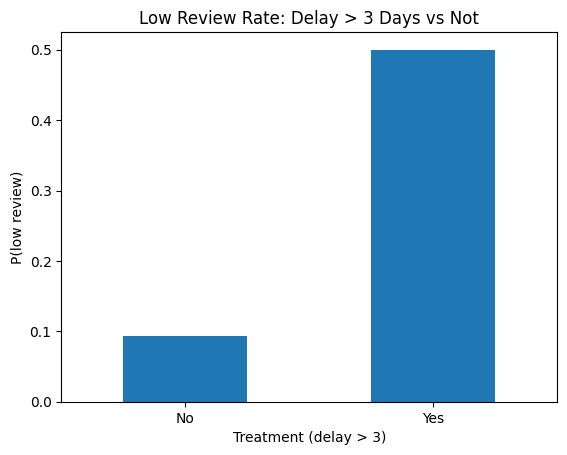

In [21]:
df['delay_gt_3'] = (df['delivery_delay_days'] > 3).astype(int)

grouped = df.groupby('delay_gt_3')['low_review'].mean()

grouped.plot(kind='bar')
plt.title("Low Review Rate: Delay > 3 Days vs Not")
plt.xlabel("Treatment (delay > 3)")
plt.ylabel("P(low review)")
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.show()

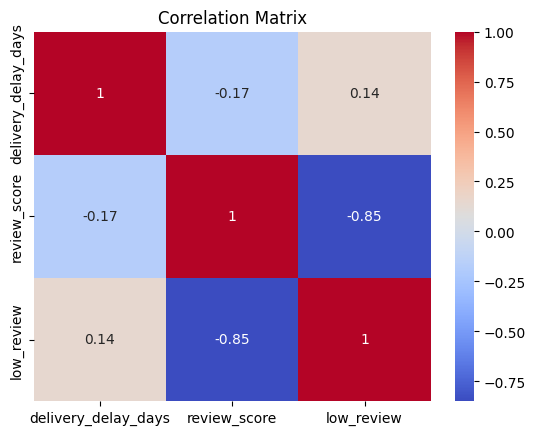

In [22]:
import seaborn as sns

cols = [
    'delivery_delay_days',
    'review_score',
    'low_review'
]

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

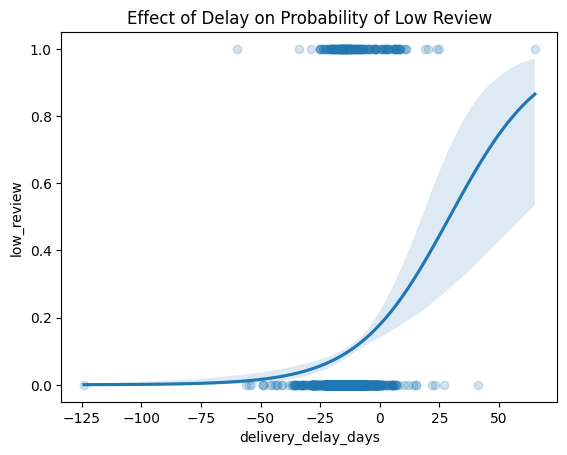

In [23]:
sns.regplot(
    x='delivery_delay_days',
    y='low_review',
    data=df,
    logistic=True,
    scatter_kws={'alpha':0.2}
)
plt.title("Effect of Delay on Probability of Low Review")
plt.show()